In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/online_retail_clean.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.shape)
df.head()

(400916, 10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12,30.0


In [5]:
# Aggregate total sales by month
monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)
monthly_sales["InvoiceDate"] = monthly_sales["InvoiceDate"].dt.to_timestamp()
monthly_sales = monthly_sales.sort_values("InvoiceDate").reset_index(drop=True)

print(monthly_sales.shape)
monthly_sales

(13, 2)


,InvoiceDate,Sales
0,2009-12-01,683504.010
1,2010-01-01,555802.672
2,2010-02-01,504558.956
3,2010-03-01,696978.471
4,2010-04-01,591982.002
5,2010-05-01,597833.380
6,2010-06-01,636371.130
7,2010-07-01,589736.170
8,2010-08-01,602224.600
9,2010-09-01,829013.951


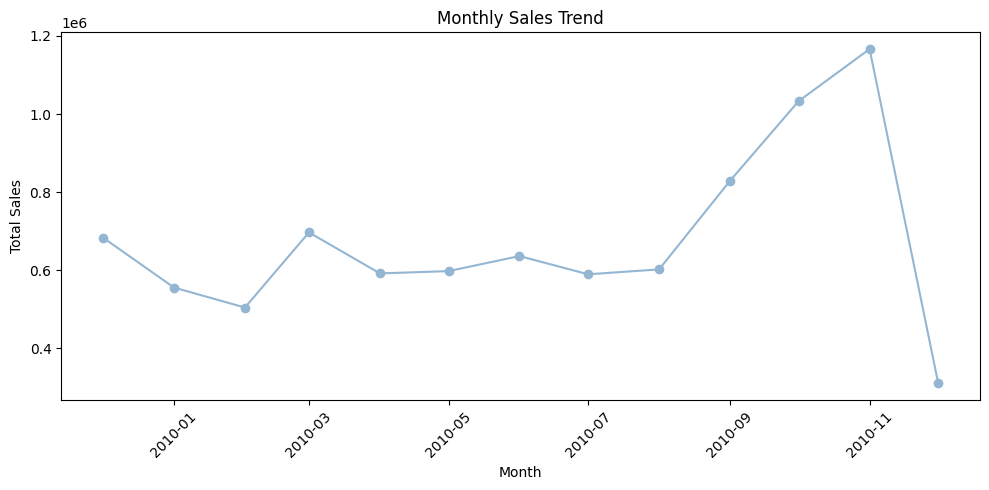

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["InvoiceDate"], monthly_sales["Sales"], marker="o", color="#94B6D2")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_trend.png", dpi=150)
plt.show()

In [7]:
monthly_sales["time_index"] = np.arange(len(monthly_sales))       # 0,1,2,3... captures trend
monthly_sales["month_num"] = monthly_sales["InvoiceDate"].dt.month # 1-12, captures seasonality

# One-hot encode month to let the model learn seasonal effects
month_dummies = pd.get_dummies(monthly_sales["month_num"], prefix="month", drop_first=True)
features = pd.concat([monthly_sales[["time_index"]], month_dummies], axis=1)
target = monthly_sales["Sales"]

features.head()

,time_index,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0,False,False,False,False,False,False,False,False,False,False,True
1,1,False,False,False,False,False,False,False,False,False,False,False
2,2,True,False,False,False,False,False,False,False,False,False,False
3,3,False,True,False,False,False,False,False,False,False,False,False
4,4,False,False,True,False,False,False,False,False,False,False,False


In [8]:
test_months = 3   # hold out the last 3 months as your test set
train_X, test_X = features.iloc[:-test_months], features.iloc[-test_months:]
train_y, test_y = target.iloc[:-test_months], target.iloc[-test_months:]

print("Train size:", train_X.shape, " Test size:", test_X.shape)

Train size: (10, 12)  Test size: (3, 12)


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train_X, train_y)

pred_y = model.predict(test_X)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_y, pred_y)
rmse = np.sqrt(mean_squared_error(test_y, pred_y))
mape = np.mean(np.abs((test_y.values - pred_y) / test_y.values)) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  447,326.33
RMSE: 459,030.79
MAPE: 84.94%


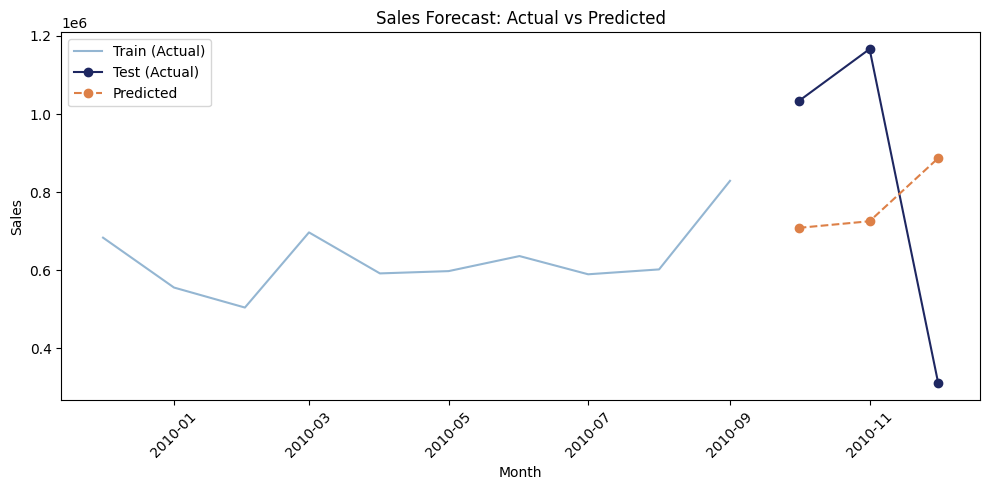

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["InvoiceDate"].iloc[:-test_months], train_y, label="Train (Actual)", color="#94B6D2")
plt.plot(monthly_sales["InvoiceDate"].iloc[-test_months:], test_y, label="Test (Actual)", color="#1E2761", marker="o")
plt.plot(monthly_sales["InvoiceDate"].iloc[-test_months:], pred_y, label="Predicted", color="#DD8047", marker="o", linestyle="--")
plt.title("Sales Forecast: Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_forecast_actual_vs_predicted.png", dpi=150)
plt.show()

In [12]:
future_periods = 3
last_index = monthly_sales["time_index"].max()
last_date = monthly_sales["InvoiceDate"].max()

future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=future_periods, freq="MS")
future_df = pd.DataFrame({
    "time_index": np.arange(last_index + 1, last_index + 1 + future_periods),
    "month_num": future_dates.month
})
future_dummies = pd.get_dummies(future_df["month_num"], prefix="month", drop_first=True)
# make sure future has same columns as training data (fill missing months with 0)
future_dummies = future_dummies.reindex(columns=month_dummies.columns, fill_value=0)
future_X = pd.concat([future_df[["time_index"]], future_dummies], axis=1)

future_forecast = model.predict(future_X)

forecast_result = pd.DataFrame({
    "Month": future_dates,
    "Forecasted_Sales": future_forecast
})
print(forecast_result)

       Month  Forecasted_Sales
0 2011-01-01     759520.402408
1 2011-02-01     708276.686408
2 2011-03-01     900696.201408


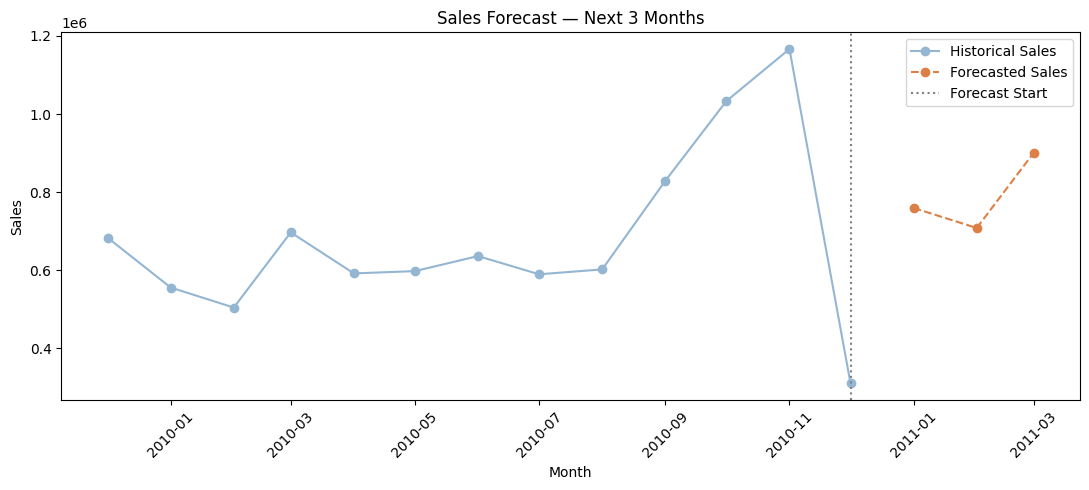

In [13]:
plt.figure(figsize=(11, 5))
plt.plot(monthly_sales["InvoiceDate"], monthly_sales["Sales"], label="Historical Sales", color="#94B6D2", marker="o")
plt.plot(forecast_result["Month"], forecast_result["Forecasted_Sales"], label="Forecasted Sales", color="#DD8047", marker="o", linestyle="--")
plt.axvline(monthly_sales["InvoiceDate"].max(), color="gray", linestyle=":", label="Forecast Start")
plt.title("Sales Forecast — Next 3 Months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_forecast_full.png", dpi=150)
plt.show()